# 12 · End-to-end domain-agnostic EDA

A compact but rich workflow showing how an arbitrary tabular dataset plus aligned feature spaces can be inspected, compared and visualized without any domain-specific logic inside Ruddy.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import AnalysisConfig, analyze
frame,dataset=load_tabular_demo(); A=load_feature_demo('representation_a'); B=load_feature_demo('representation_b')
config=AnalysisConfig(enabled_blocks=('profiling','univariate','bivariate','groups','outliers','pca','permanova','representation','anomaly'),responses=('activity',),groups=('group',),permanova_factor='group',permanova_permutations=19,representation_cca_components=3,representation_mantel_permutations=19,projection_n_components=3,random_state=42)
res=analyze(dataset,config=config,features=A,comparison_features=B)
print('Executed blocks:',[str(x) for x in res.executed_blocks]); display(pd.DataFrame([res.profiling.overview]))

Executed blocks: ['profiling', 'univariate', 'bivariate', 'groups', 'outliers', 'pca', 'permanova', 'representation', 'anomaly']


,n_records,n_columns,column_roles,column_kinds,column_quality,missingness,duplicates,identifier
0,180,15,"{'identifier': 1, 'variable': 6, 'response': 2...","{'numeric': 7, 'categorical': 6, 'boolean': 1,...","{'n_analysis_eligible': 14, 'n_excluded': 0, '...","{'n_missing_cells': 3, 'missing_fraction': 0.0...","{'n_duplicate_rows': 0, 'n_records_in_duplicat...","{'column': 'id', 'source': 'column', 'n_presen..."


## From raw group distributions to structured inference

findfont: Failed to find font weight semibold, now using 700.


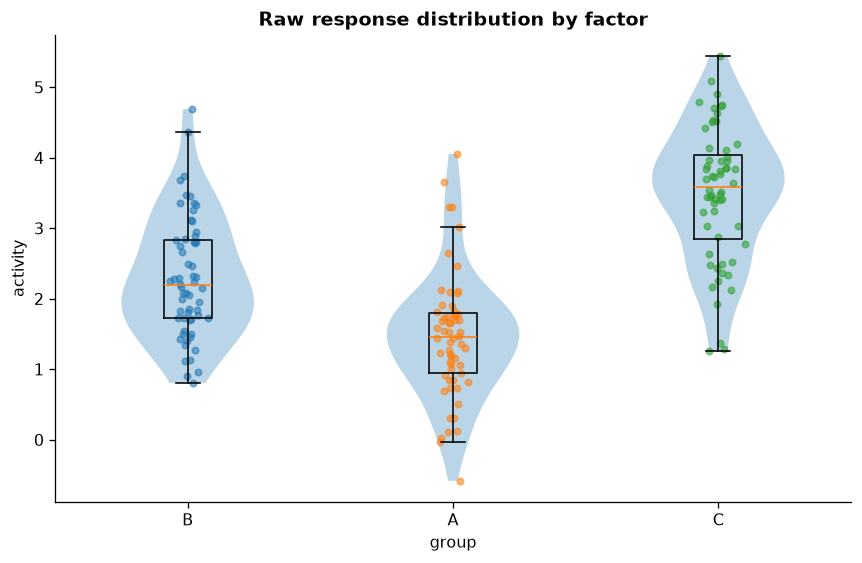

In [2]:
group_violin_box_scatter(frame,value='activity',group='group',title='Raw response distribution by factor'); plt.show()

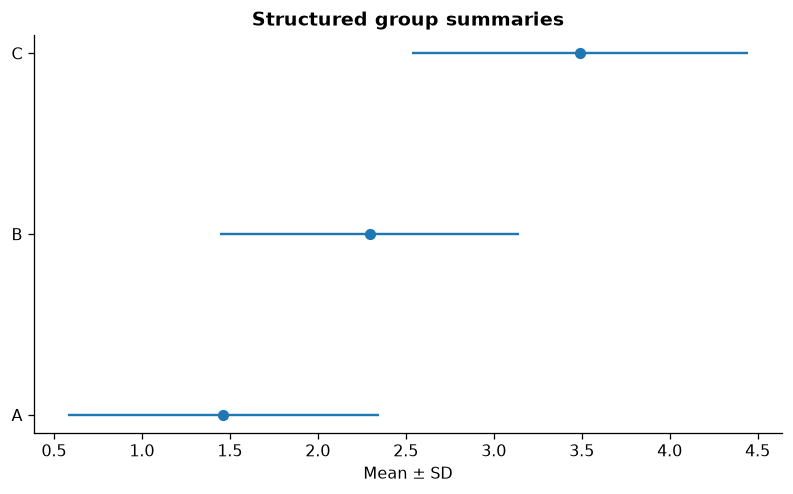

In [3]:
s=res.groups.numeric_summaries.query('response=="activity" and group_column=="group"'); fig,ax=plt.subplots(figsize=(7,4.4)); ax.errorbar(s['mean'],np.arange(len(s)),xerr=s['std'],fmt='o'); ax.set_yticks(np.arange(len(s)),s.group_level.astype(str)); ax.set_xlabel('Mean ± SD'); ax.set_title('Structured group summaries'); finish(fig); plt.show()

## Feature-space organization

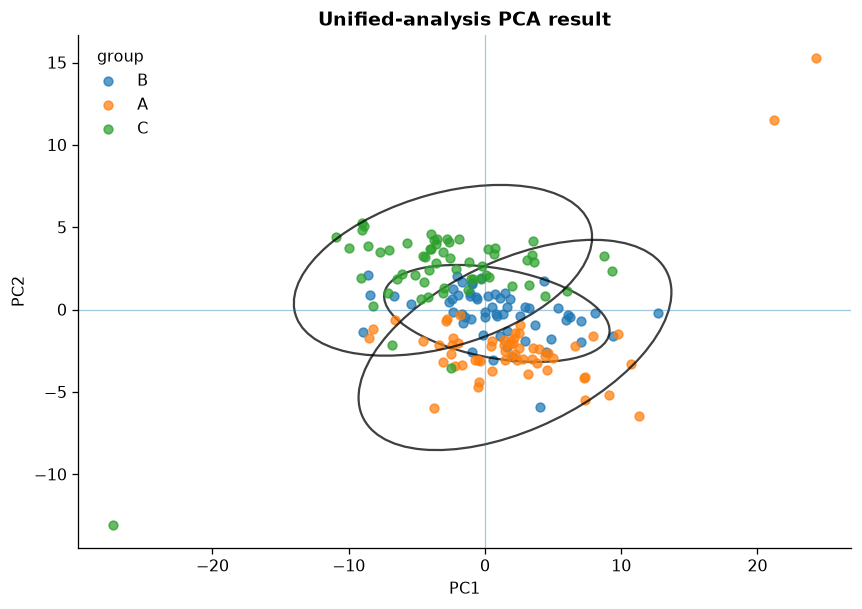

In [4]:
score_plot(res.pca.scores,frame,x='PC1',y='PC2',group='group',title='Unified-analysis PCA result',ellipses=True); plt.show()

## Statistical outliers vs representation anomalies

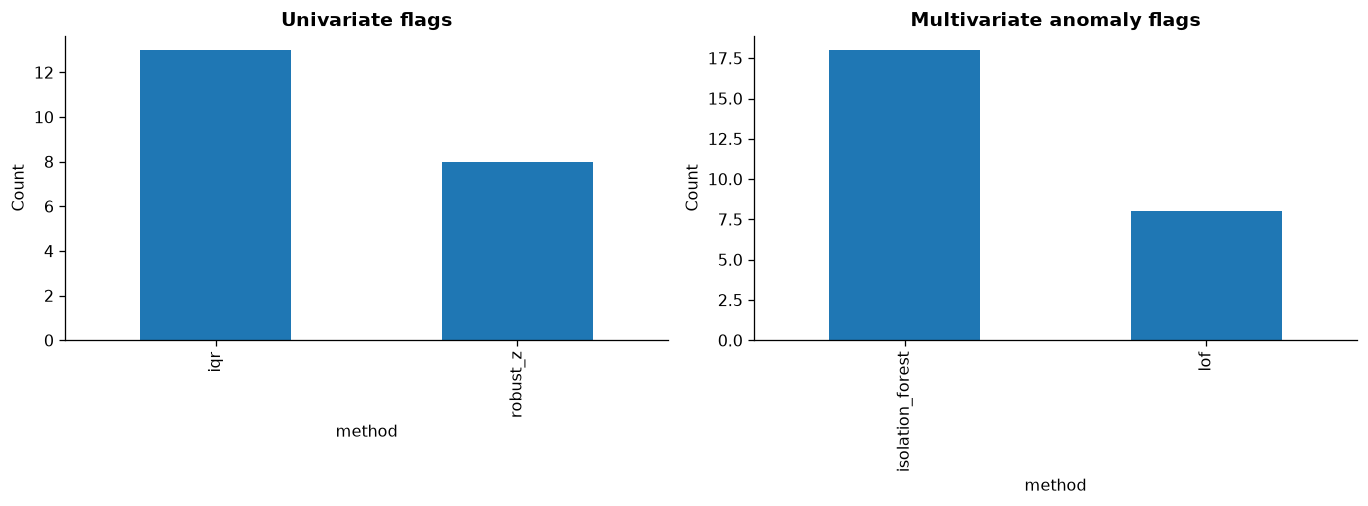

In [5]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5));
res.outliers.summaries.query('status=="ok"').groupby('method').n_flagged.sum().plot(kind='bar',ax=axes[0]); axes[0].set_title('Univariate flags'); axes[0].set_ylabel('Count')
res.anomaly.scores.groupby('method').is_flagged.sum().plot(kind='bar',ax=axes[1]); axes[1].set_title('Multivariate anomaly flags'); axes[1].set_ylabel('Count'); finish(fig); plt.show()

## Representation similarity

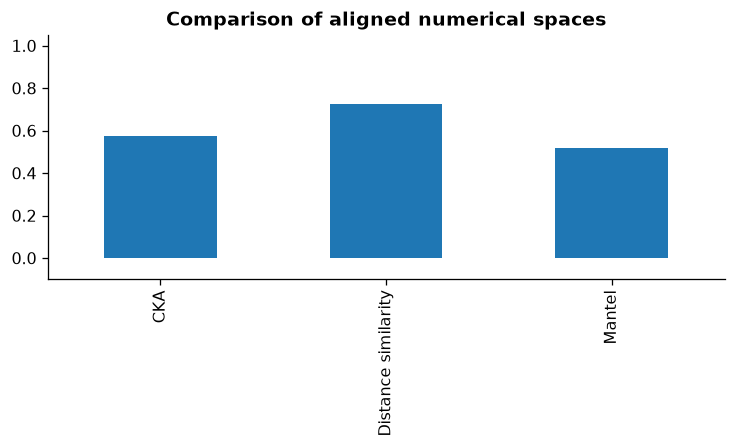

,analysis,factor,statistic,value,df_between,df_within,r_squared,p_value,n_permutations,status,reason
0,permanova,group,pseudo_f,21.132665,2,177,0.192759,0.05,19,ok,None
1,permdisp,group,f_value,0.545723,2,177,NaN,0.55,19,ok,None


In [6]:
metrics=pd.Series({'CKA':res.representation.cka.iloc[0].cka,'Distance similarity':res.representation.distance_similarity.iloc[0].coefficient,'Mantel':res.representation.mantel.iloc[0].correlation}); fig,ax=plt.subplots(figsize=(6.5,4)); metrics.plot(kind='bar',ax=ax); ax.set_ylim(-.1,1.05); ax.set_title('Comparison of aligned numerical spaces'); finish(fig); plt.show(); display(res.permanova.summary)

## Unified result map

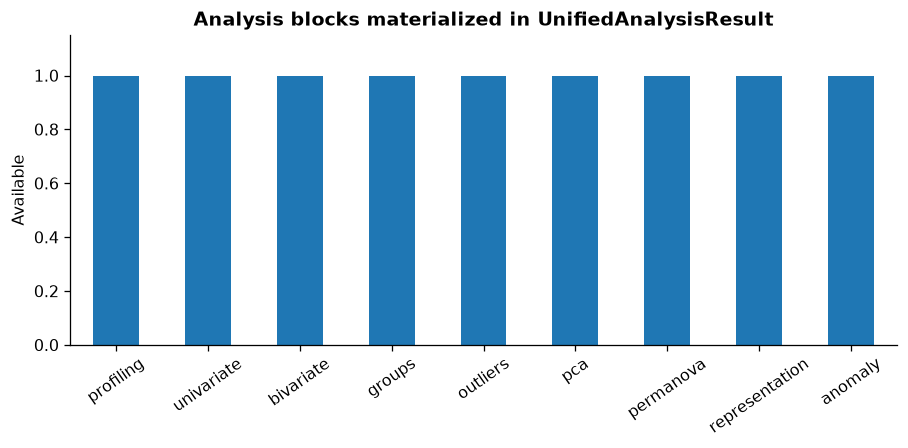

In [7]:
present=pd.Series({name:(value is not None) for name,value in res.components.items()}); fig,ax=plt.subplots(figsize=(8,4)); present.astype(int).plot(kind='bar',ax=ax); ax.set_ylim(0,1.15); ax.set_ylabel('Available'); ax.set_title('Analysis blocks materialized in UnifiedAnalysisResult'); ax.tick_params(axis='x',rotation=35); finish(fig); plt.show()